# Stage 2: Exploratory Data Analysis & Pre-Processing of Telco's Customer Churn

### This section explores the dataset, understanding and preparing the dataset before processing the model.

**Objective:** Explore the data, Check data quality, Visualise patterns, & prepare the data for modelling 

Group 11: Tai Jing, Kael Maliq, Ayan Ahmad, Muhammad Pratama

**1. Load the dataset.**

The following section will import necessary libraries and read dataset off available CSV file.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [31]:
data_path = "data/Telco_customer_churn.csv"
df = pd.read_csv(data_path)

**2. Initial Exploration of Data**
   
The following section will load and initially explore the dataset to understand its size, structure, and column types.

In [32]:
df.shape

(7043, 33)

In [33]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [35]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


**3. Data Quality Checks**

The following section will look for missing values, duplicates, and inconsistent types.

a) change inconsistent type to numeric form.

In [36]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

b) Check all values that are null.

In [37]:
df.isnull().sum().sort_values(ascending=False)

Churn Reason         5174
Total Charges          11
Online Security         0
CLTV                    0
Churn Score             0
Churn Value             0
Churn Label             0
Monthly Charges         0
Payment Method          0
Paperless Billing       0
Contract                0
Streaming Movies        0
Streaming TV            0
Tech Support            0
Device Protection       0
Online Backup           0
CustomerID              0
Count                   0
Multiple Lines          0
Phone Service           0
Tenure Months           0
Dependents              0
Partner                 0
Senior Citizen          0
Gender                  0
Longitude               0
Latitude                0
Lat Long                0
Zip Code                0
City                    0
State                   0
Country                 0
Internet Service        0
dtype: int64

c) Put in percentage form

In [38]:
(df.isnull().sum().sort_values(ascending=False) / len(df)) * 100

Churn Reason         73.463013
Total Charges         0.156183
Online Security       0.000000
CLTV                  0.000000
Churn Score           0.000000
Churn Value           0.000000
Churn Label           0.000000
Monthly Charges       0.000000
Payment Method        0.000000
Paperless Billing     0.000000
Contract              0.000000
Streaming Movies      0.000000
Streaming TV          0.000000
Tech Support          0.000000
Device Protection     0.000000
Online Backup         0.000000
CustomerID            0.000000
Count                 0.000000
Multiple Lines        0.000000
Phone Service         0.000000
Tenure Months         0.000000
Dependents            0.000000
Partner               0.000000
Senior Citizen        0.000000
Gender                0.000000
Longitude             0.000000
Latitude              0.000000
Lat Long              0.000000
Zip Code              0.000000
City                  0.000000
State                 0.000000
Country               0.000000
Internet

In [39]:
df.duplicated().sum()

np.int64(0)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

### Univariate Analysis

**4. Analysis on Key Numeric Customer Variables.**

The following section will explore the main numeric variables of this business. Looking into amount of churns, percentages, and visualisations of data using graphs and charts.

In [41]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [42]:
df["Churn Label"].value_counts(normalize=True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

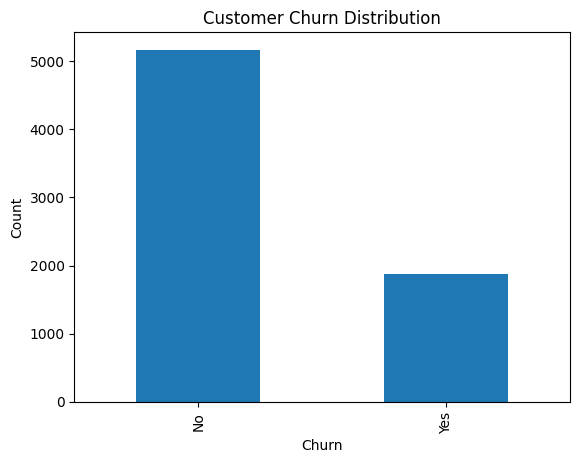

In [43]:
df["Churn Label"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

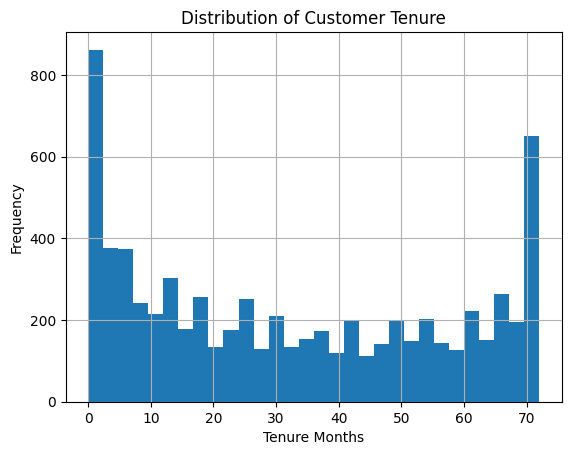

In [44]:
df["Tenure Months"].hist(bins=30)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure Months")
plt.ylabel("Frequency")
plt.show()

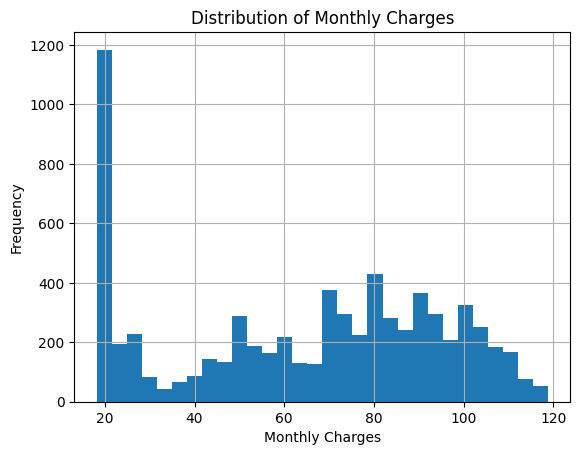

In [45]:
df["Monthly Charges"].hist(bins=30)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

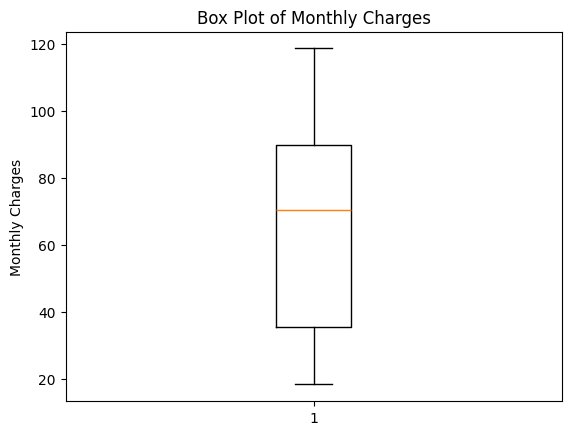

In [46]:
plt.boxplot(df["Monthly Charges"])

plt.title("Box Plot of Monthly Charges")
plt.ylabel("Monthly Charges")

plt.show()

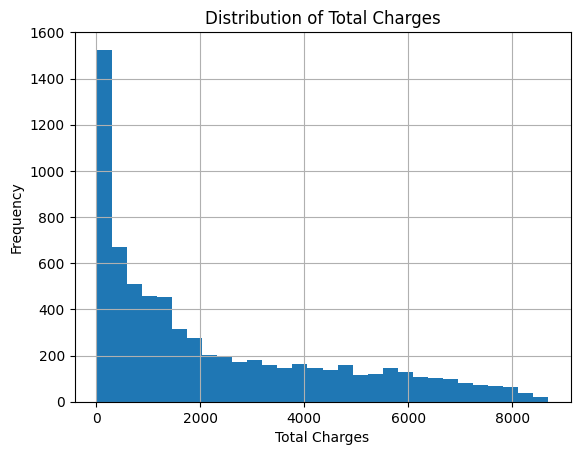

In [50]:
df["Total Charges"].dropna().hist(bins=30)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Frequency")

plt.show()

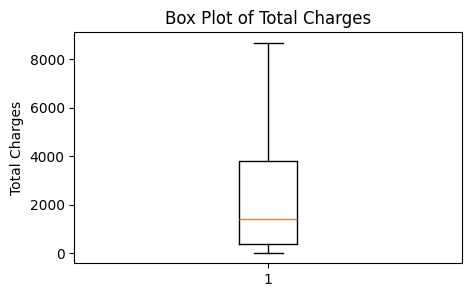

In [55]:
plt.figure(figsize=(5,3))
plt.boxplot(df["Total Charges"].dropna())

plt.title("Box Plot of Total Charges")
plt.ylabel("Total Charges")

plt.show()

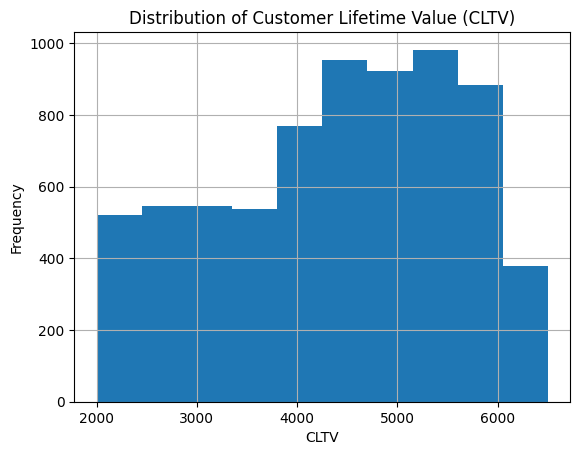

In [56]:
df["CLTV"].hist()

plt.title("Distribution of Customer Lifetime Value (CLTV)")
plt.xlabel("CLTV")
plt.ylabel("Frequency")

plt.show()

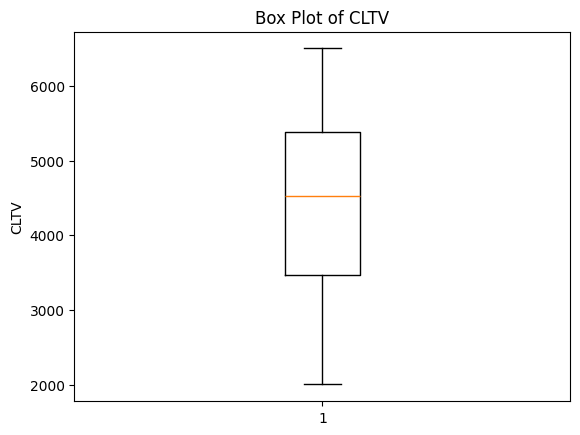

In [21]:
plt.boxplot(df["CLTV"])

plt.title("Box Plot of CLTV")
plt.ylabel("CLTV")

plt.show()

## Bivariate / Multivariate Analysis

**6. Analysis on customer churn against a variety of variables.**

The following section will see churn against multiple different variables in the dataset.

In [33]:
# Contract type against churn (shows strong churn pattern)
pd.crosstab(df["Contract"], df["Churn Label"])

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [32]:
pd.crosstab(df["Contract"], df["Churn Label"], normalize="index") * 100

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858
